# Transformer From Scratch

Based on Neel Nanda's GPT-2 From Scratch

Adapted to use only PyTorch and NumPy (+ HuggingFace for the reference model). Neel's EasyTransformers is great, but it's changed quite a bit!

Did a full write-up here, with an explanation (credit to Neel's videos!) and some additional exploration: https://emma-x1.github.io/writing/transformer-from-scratch

Major adaptations:
- The order is a little different (to me it made more sense to think about embedding before `LayerNorm`), and I tried to explain each layer myself in a way that made sense to me, showing the tensors whenever possible.

(Some of the) Technical changes:
- `model(x)` returns a `CausalLMOutputWithCrossAttentions`, which is a named tuple with `.logits`, `.past_key_values`, `.hidden_states`, `.attentions` - not just logits
- `run_with_cache` gives entries even for sub modules, use `c_attn` for concatenated QKV matrix `[B, T, 3*d_model]` before split
- Attention returns a tuple `(attn_output, present_key_value, attn_weights)`, so `output[0]` is the post-attention residual contribution that gets added back to the stream
- Testing (`load_gpt_2_test`) is quite a bit more involved, Neel's library does a great job simplifying it so there's quite a bit of adaptation here

# Setup, Utilities, etc

In [91]:
%pip install transformers
%pip install fancy_einsum
%pip install einops


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [92]:
import einops # for tensor expressions
from fancy_einsum import einsum 
from dataclasses import dataclass # decorators, to allow us to pass a config around
import torch # classic for all deep learning
import torch.nn as nn 
import numpy as np # for all sorts of math functions
import math
import tqdm.auto as tqdm # to show progress bars :)

In [96]:
#Config object to set params of the model - we copy GPT-2's parameters, but would be interesting to play around with these
@dataclass
class Config:
    d_model: int = 768 # dimensionality of the residual stream
    debug: bool = True # printing tensor shapes for debugging
    layer_norm_epsilon: float = 1e-5 # added in layernorm to prevent division by 0
    d_vocab: int = 50257 # size of our vocabulary 'dictionary' - depends on the tokenizer
    init_range: float = 0.02
    n_ctx: int = 1024 # maximum number of tokens in a sequence, "context window"
    d_head: int = 64 # dimension per attention head (d_model / n_heads)
    d_mlp: int = 3072 # size of the MLP layer (4 * d_model)
    n_heads: int = 12 # number of attention heads
    n_layers: int = 12 # number of transformer blocks
    
cfg = Config()
print(cfg)

Config(d_model=768, debug=True, layer_norm_epsilon=1e-05, d_vocab=50257, init_range=0.02, n_ctx=1024, d_head=64, d_mlp=3072, n_heads=12, n_layers=12)


## Reference Model

Loading the reference GPT-2 model from HuggingFace, used to check and compare against our implementation.

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(device)
device = "cpu" # hard-code, some operations not yet supported on mps

model_name = "gpt2"  # this is gpt2-small

reference_gpt2 = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

reference_gpt2.eval() # set to inference mode, not training mode

mps


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [99]:
print(reference_gpt2)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [157]:
# helpers

# TODO come back
def run_with_cache(model, tokens):
    cache = {}
    hooks = []
    
    def make_hook(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                cache[name] = output.detach()
            elif isinstance(output, tuple) and isinstance(output[0], torch.Tensor):
                cache[name] = output[0].detach()
        return hook
    
    for name, module in model.named_modules():
        hooks.append(module.register_forward_hook(make_hook(name)))
        
    with torch.no_grad():
        out = model(tokens)
        
    for h in hooks:
        h.remove()
        
    return out.logits, cache

Key:
batch = 1
position = 35
d_model = 768
n_heads = 12
n_layers = 12
d_mlp = 3072 (4 * d_model)
d_head = 64 (d_model / n_heads)

In [165]:
# text to tokens
reference_text = "To be, or not to be. That is the question "
tokens = tokenizer.encode(reference_text, return_tensors="pt").to(device)
print(tokens)
print(tokens.shape) # [batch, position]
print(tokenizer.convert_ids_to_tokens(tokens[0].tolist()))

tensor([[2514,  307,   11,  393,  407,  284,  307,   13, 1320,  318,  262, 1808,
          220]])
torch.Size([1, 13])
['To', 'Ġbe', ',', 'Ġor', 'Ġnot', 'Ġto', 'Ġbe', '.', 'ĠThat', 'Ġis', 'Ġthe', 'Ġquestion', 'Ġ']


In [166]:
# tokens to logits
logits, cache = run_with_cache(reference_gpt2, tokens)
print(logits.shape) # [batch, position]

torch.Size([1, 13, 50257])


In [160]:
# logits to distribution
log_probs = logits.log_softmax(dim=-1)
probs = logits.softmax(dim=-1)
print(log_probs.shape)
print(probs.shape)

torch.Size([1, 5, 50257])
torch.Size([1, 5, 50257])


In [167]:
# distribution to token
last_logits = logits[0, -1]
next_token = last_logits.argmax(dim=-1) # -1 for the last token
print(last_logits)
print(next_token)
print(tokenizer.decode([next_token.item()]))

tensor([-65.8917, -66.7953, -69.4056,  ..., -76.4184, -73.3271, -69.4449])
tensor(1849)
 


In [168]:
# repeat!
next_tokens = torch.cat(
    [tokens, next_token.reshape(1,1)], dim=-1)

with torch.no_grad():
    new_output = reference_gpt2(next_tokens)
    
new_logits = new_output.logits # [batch, position, vocab_size]

print("New input (tokens):", next_tokens)
print(next_tokens.shape)
print("New input (text):", tokenizer.decode(next_tokens[0].tolist()))

print(new_logits.shape)

predicted_token_id = new_logits[0, -1].argmax(-1)
print("Predicted next token:", tokenizer.decode([predicted_token_id.item()]))

New input (tokens): tensor([[2514,  307,   11,  393,  407,  284,  307,   13, 1320,  318,  262, 1808,
          220, 1849]])
torch.Size([1, 14])
New input (text): To be, or not to be. That is the question  
torch.Size([1, 14, 50257])
Predicted next token: of


In [136]:
# Activation Shapes
for activation_name, activation in cache.items():
    if not hasattr(activation, 'shape'):
        continue
    is_block_0 = "transformer.h.0" in activation_name
    is_top_level = "transformer.h" not in activation_name and activation_name != ""
    if is_block_0 or is_top_level: # only first block
        print(activation_name, tuple(activation.shape))

transformer.wte (1, 13, 768)
transformer.wpe (1, 13, 768)
transformer.drop (1, 13, 768)
transformer.h.0.ln_1 (1, 13, 768)
transformer.h.0.attn.c_attn (1, 13, 2304)
transformer.h.0.attn.c_proj (1, 13, 768)
transformer.h.0.attn.resid_dropout (1, 13, 768)
transformer.h.0.attn (1, 13, 768)
transformer.h.0.ln_2 (1, 13, 768)
transformer.h.0.mlp.c_fc (1, 13, 3072)
transformer.h.0.mlp.act (1, 13, 3072)
transformer.h.0.mlp.c_proj (1, 13, 768)
transformer.h.0.mlp.dropout (1, 13, 768)
transformer.h.0.mlp (1, 13, 768)
transformer.h.0 (1, 13, 768)
transformer.ln_f (1, 13, 768)
lm_head (1, 13, 50257)


## Test

In [169]:
# get_corner returns top-left corner of last two dimensions 
def get_corner(tensor, n=3):
    return tensor[..., :n, :n]

In [170]:
# generate tensor of floats
def rand_float_test(cls, shape):
    cfg = Config(debug=True)
    layer = cls(cfg)
    random_input = torch.randn(shape) # standard gaussian
    print("Input shape:", random_input.shape)
    output = layer(random_input)
    print("Output shape:", output.shape)
    print(get_corner(output))
    return output

# generate tensor of ints
def rand_int_test(cls, shape):
    cfg = Config(debug=True)
    layer = cls(cfg)
    random_input = torch.randint(low=0, high=cfg.d_vocab, size=shape) # standard gaussian
    print("Input shape:", random_input.shape)
    output = layer(random_input)
    print("Output shape:", output.shape)
    print(get_corner(output))
    return output

# testing our impl against base model
def load_gpt2_test(cls, gpt2_layer, input_name, gpt2_layer_output):
    cfg = Config(debug=True)
    layer = cls(cfg)
    layer.load_state_dict(gpt2_layer.state_dict(), strict=False)
    if isinstance(input_name, str):
        reference_input = cache[input_name]
    else:
        reference_input = input_name
    print("Input shape:", reference_input.shape)
    output = layer(reference_input) # output is our impl run on the input
    print("Output shape:", output.shape)
    print("Reference output shape:", gpt2_layer_output.shape)
    
    comparison = torch.isclose(output, gpt2_layer_output, atol=1e-4, rtol=1e-3)
    print(f"{comparison.sum()/comparison.numel():.2%} of values are correct")
    return output


# Embedding

- A lookup table from input token to vector
- This is batched - we process `batch` tokens at a time 

Input:
- We take an input `tokens` of dimensions `[batch, n_ctx]`

Embed: 
- Embed applies a weight matrix of dimensions `[d_vocab, d_model]` - a lookup table
    - This is what learning does - it updates the weights, initially initialized randomly, so that it can more closely approximate the data thereby 'learning'

Output:
- Matrix representing the embedded token values of size `[batch, n_ctx, d_model]`

In [ ]:
class Embed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # nn.Parameter is a tensor, treated as a learnable weight - ie. we'll tune this
        # self.weight is 'syntactic sugar' - we don't do every matrix multiplication since most entries are 0s
        self.weight = nn.Parameter(torch.randn(cfg.d_vocab, cfg.d_model)) # why 0.02? why not?
        nn.init.normal_(self.weight, std=self.cfg.init_range) # this relates to initialization theory - a whole fascinating field
    
    def forward(self, tokens):
        # tokens: [batch, n_ctx]
        if cfg.debug: print("Tokens:", tokens.shape)
        embed = self.weight[tokens, :] # [batch, n_ctx, d_model]
        if cfg.debug: print("Embeddings:", embed.shape)
        return embed

In [176]:
x = torch.randint(low=0, high=cfg.d_vocab, size=[2,4])
reference_output = reference_gpt2.transformer.wte(x)
load_gpt2_test(Embed, reference_gpt2.transformer.wte, x, reference_output)

Input shape: torch.Size([2, 4])
Tokens: torch.Size([2, 4])
Embeddings: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Reference output shape: torch.Size([2, 4, 768])
100.00% of values are correct


tensor([[[ 0.0139, -0.0812,  0.2779,  ...,  0.0686, -0.2544, -0.0230],
         [ 0.0436, -0.1653, -0.1188,  ..., -0.3219, -0.1544,  0.0773],
         [ 0.1907, -0.2187,  0.0566,  ..., -0.2027, -0.1969, -0.1703],
         [ 0.1138,  0.0311,  0.2391,  ..., -0.0855, -0.0820, -0.2726]],

        [[ 0.1130,  0.1598,  0.0361,  ..., -0.1270,  0.0541,  0.0162],
         [ 0.0147, -0.0211,  0.0836,  ...,  0.0279, -0.0255,  0.0017],
         [ 0.0996,  0.0932,  0.0226,  ..., -0.0714,  0.1420,  0.1373],
         [-0.0864,  0.1069,  0.2707,  ..., -0.0270, -0.1055,  0.1130]]],
       grad_fn=<IndexBackward0>)

# Postitional Embedding
- We add information about the position of each token. 
- Later, we'll add this to the `Embed` matrix. Note that we're working in such a high dimensionality that simply adding the matrices just *works* without too much interference

Input: 
- Same tokens from `Embed` of size `[batch, n_ctx]`

Positional Embedding:
- We apply a 

Output:


In [180]:
class PosEmbed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # torch.empty allocates the memory but doesn't initialize it - faster than zeros or randn, since we're initializing weights on the next line
        self.weight  = nn.Parameter(torch.empty((cfg.n_ctx, cfg.d_model)))
        nn.init.normal_(self.weight, std=self.cfg.init_range)
        
    def forward(self, tokens):
        # tokens: [batch, position]
        if cfg.debug: print("Tokens:", tokens.shape)
        # self.weight[:tokens.size(1), :] applies weight based on the position of the word (as opposed to the token value)
        pos_embed = self.weight[:tokens.size(1), :] # [position, d_model]
        # einops.repeat repeats this positional embedding across all rows
        # the equivalent without einops would be: pos_embed = pos_embed.unsqueeze(0).expand(tokens.size(0), -1, -1)
        pos_embed = einops.repeat(pos_embed, "position d_model -> batch position d_model", batch=tokens.size(0))
        if cfg.debug: print("Positional Embeddings:", pos_embed.shape)
        return pos_embed

In [181]:
x = torch.randint(low=0, high=cfg.n_ctx, size=[2,4])
reference_output = reference_gpt2.transformer.wpe(x)
load_gpt2_test(PosEmbed, reference_gpt2.transformer.wpe, x, reference_output)

Input shape: torch.Size([2, 4])
Tokens: torch.Size([2, 4])
Positional Embeddings: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Reference output shape: torch.Size([2, 4, 768])
0.36% of values are correct


tensor([[[-1.8821e-02, -1.9742e-01,  4.0267e-03,  ..., -4.3044e-02,
           2.8267e-02,  5.4490e-02],
         [ 2.3959e-02, -5.3792e-02, -9.4879e-02,  ...,  3.4170e-02,
           1.0172e-02, -1.5573e-04],
         [ 4.2161e-03, -8.4764e-02,  5.4515e-02,  ...,  1.9745e-02,
           1.9325e-02, -2.1424e-02],
         [-2.8337e-04, -7.3803e-02,  1.0553e-01,  ...,  1.0157e-02,
           1.7659e-02, -7.0854e-03]],

        [[-1.8821e-02, -1.9742e-01,  4.0267e-03,  ..., -4.3044e-02,
           2.8267e-02,  5.4490e-02],
         [ 2.3959e-02, -5.3792e-02, -9.4879e-02,  ...,  3.4170e-02,
           1.0172e-02, -1.5573e-04],
         [ 4.2161e-03, -8.4764e-02,  5.4515e-02,  ...,  1.9745e-02,
           1.9325e-02, -2.1424e-02],
         [-2.8337e-04, -7.3803e-02,  1.0553e-01,  ...,  1.0157e-02,
           1.7659e-02, -7.0854e-03]]], grad_fn=<ExpandBackward0>)

# LayerNorm

- Applied at the start of each layer (MLP, attention)
- Normalizing function, taking an input vector and transforming it to have mean = 0 and variance = 1
- Also applies some non-linear scaling with the learned weights
- Neel describes this as an area where pretty cool math takes place - elementwise scaling and translation 

Input:
- `residual` is the embedded tokens, of dimensionality `[batch, position, d_model]`

LayerNorm:
- We have a `weight` - a tensor of dimension `[d_model]` consisting of all ones
- We have a `bias` - a tensor of dimension `[d_model]` consisting of all zeros

Output:
- Matrix of size `[batch, position, d_model]`

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(cfg.d_model)) # norm by default = 1
        self.bias = nn.Parameter(torch.zeros(cfg.d_model)) # mean by default = 0
        
    def forward(self, residual):
        # residual: [batch, position, d_model]
        if cfg.debug: print("Residual:", residual.shape)
        # einops.reduce collapses the dimension, default by averaging
        residual = residual - einops.reduce(residual, "batch position d_model -> batch position 1", "mean")
        # calculate variance and square root, then add epsilon to ensure non-zero
        #   variance: sum of squares / n
        scale = (einops.reduce(residual.pow(2), "batch position d_model -> batch position 1", "mean") + cfg.layer_norm_epsilon).sqrt()
        residual = residual / scale
        normalized = residual * self.weight + self.bias
        if cfg.debug: print("Normalized:", residual.shape)
        return normalized

In [183]:
x = rand_float_test(LayerNorm, [2, 4, 768])
reference_output = reference_gpt2.transformer.h[0].ln_1(x)
load_gpt2_test(LayerNorm, reference_gpt2.transformer.h[0].ln_1, x, reference_output)

Input shape: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
tensor([[[ 0.3715, -0.4083, -0.2473],
         [-1.1620, -0.6428,  0.1969],
         [-0.1352, -0.8354,  1.0757]],

        [[ 0.4552,  0.6216, -0.0553],
         [ 0.1175, -1.6006, -0.8773],
         [ 0.6398, -0.9439,  0.5673]]], grad_fn=<SliceBackward0>)
Input shape: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Reference output shape: torch.Size([2, 4, 768])
100.00% of values are correct


tensor([[[ 0.0792, -0.0471, -0.1020,  ..., -0.2265, -0.0275, -0.1517],
         [-0.2631, -0.0898, -0.0338,  ..., -0.1779,  0.0739, -0.0846],
         [-0.0338, -0.1248,  0.1010,  ...,  0.0253, -0.1938,  0.0532],
         [ 0.3894,  0.1486,  0.0089,  ...,  0.1543,  0.0497, -0.0069]],

        [[ 0.0979,  0.1403, -0.0725,  ...,  0.2115,  0.0636, -0.2717],
         [ 0.0225, -0.2641, -0.1986,  ..., -0.2211, -0.0054, -0.1813],
         [ 0.1391, -0.1445,  0.0230,  ...,  0.4904, -0.2427,  0.3728],
         [ 0.2868, -0.3955,  0.0192,  ...,  0.1808, -0.1853,  0.1147]]],
       grad_fn=<AddBackward0>)

# Attention
- This is the only step that moves information from a prior position in the sequence to the current one
- We parallelize this - we do this for each token for all prefix token strings
- n_heads means we compute multiple attention matrices for each sequence - essentially capturing different types of dependencies between words

Input:
- The residual stream of tokens, `normalized_resid_pre` of size `[batch, position, d_model]`

Attention:
- Query, key, value weights and biases, as well as an output weight and bias, each of size `[n_heads, d_model, d_head]`
- Output an attention mask, then applied to the residual stream

Output:


* Step 1: Produce attention pattern. For each destination token, produce a probability distribution over all previous tokens including itself
    * Linear map from input -> query, key shape [batch, position, head_index, d_head]
    * Dot product every pair of queries and keys to get attn_scores [batch, head_index, query_pos, key_pos] (query = dest, key = source)
    * Scale and mask attn_scores to make it lower triangular (remember when they said linear algebra would be useful?)
    * Softmax row-wise to get prob distribution along each key_pos dimension as attention pattern
* Step 2: Move info from source token to destination token using attention pattern (move via applying linear map)
    * Linear map from input -> value [batch, key_pos, head_index, d_head]
    * Mix along key_pos with attention pattern to get intermediate z [batch, query_pos, head_index, d_head]
    * Map to output [batch, position, d_model] (where position = query_pos summed over all heads)

In [205]:
# to visualize reference gpt attention
for k, v in reference_gpt2.transformer.h[0].attn.state_dict().items():
    print(k, v.shape)
    
# in reference_gpt2, we have c_attn.weight and c_attn.bias (which packages Q, K, V altogether) and c_proj.weight and c_proj.bias (W_O, b_O). 
# separate them by splitting

W_Q, W_K, W_V = reference_gpt2.transformer.h[0].attn.state_dict()["c_attn.weight"].split(768, dim=1)  # each [768, 768]
W_Q.T.reshape(cfg.n_heads, cfg.d_head, cfg.d_model).permute(0, 2, 1)  # [n_heads, d_model, d_head]
W_K.T.reshape(cfg.n_heads, cfg.d_head, cfg.d_model).permute(0, 2, 1) 
W_V.T.reshape(cfg.n_heads, cfg.d_head, cfg.d_model).permute(0, 2, 1)  # → [n_heads, d_model, d_head]


c_attn.weight torch.Size([768, 2304])
c_attn.bias torch.Size([2304])
c_proj.weight torch.Size([768, 768])
c_proj.bias torch.Size([768])


tensor([[[ 1.4213e-01,  3.2920e-02, -6.6679e-02,  ..., -1.7292e-02,
           1.2237e-01,  1.9954e-03],
         [ 1.6184e-02, -6.3328e-02, -6.3612e-02,  ...,  1.8086e-02,
           4.7454e-02, -2.1912e-02],
         [ 2.2934e-02, -8.2780e-02,  4.3655e-02,  ...,  8.0492e-03,
          -2.9594e-02, -2.7042e-02],
         ...,
         [-9.1288e-03, -1.1456e-01,  1.0232e-01,  ..., -6.2961e-02,
          -4.7726e-05, -1.9103e-02],
         [ 8.3785e-02, -1.2905e-01, -1.4942e-01,  ...,  6.1911e-02,
          -1.2579e-01,  4.6272e-02],
         [-3.4144e-02,  3.3618e-03,  2.0308e-02,  ..., -6.2119e-02,
           7.5056e-02, -5.5417e-02]],

        [[ 6.0746e-02, -5.4322e-03,  3.1356e-02,  ...,  2.0707e-02,
          -1.1467e-01,  6.8145e-02],
         [ 2.2039e-02,  5.3950e-02,  3.8485e-03,  ...,  1.4869e-01,
          -1.0312e-02, -4.1186e-03],
         [-9.5968e-03, -6.7799e-02, -2.0372e-02,  ..., -7.1049e-02,
          -8.4796e-03,  7.6508e-02],
         ...,
         [-6.4680e-03,  2


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
['transformer.h.0.attn.c_attn', 'transformer.h.0.attn.c_proj', 'transformer.h.0.attn.resid_dropout', 'transformer.h.0.attn']
tensor([[[ 4.2605e-01, -7.5509e-02,  5.7824e-01,  ...,  1.7486e-02,
          -2.2728e-02,  3.1004e-03],
         [-6.6454e-01,  3.1189e-02,  6.0515e-01,  ...,  1.3546e-02,
           3.4185e-02,  1.1183e-02],
         [ 1.7159e-01, -1.6169e-01,  4.2875e-01,  ...,  4.5647e-02,
           2.2747e-02, -2.0801e-02],
         ...,
         [-1.4550e+00,  8.6033e-01,  8.4153e-01,  ..., -6.1363e-03,
           9.3546e-03, -2.4624e-02],
         [-2.6199e-01,  9.1021e-01,  2.7635e-01,  ...,  1.7936e-02,
          -4.5332e-03, -2.9070e-02],
         [-3.0662e-01, -5.2236e-01,  5.4170e-01,  ..., -1.7592e-02,
           1.4933e-04,  3.3284e-02]]])
torch.Size([1, 13, 768])


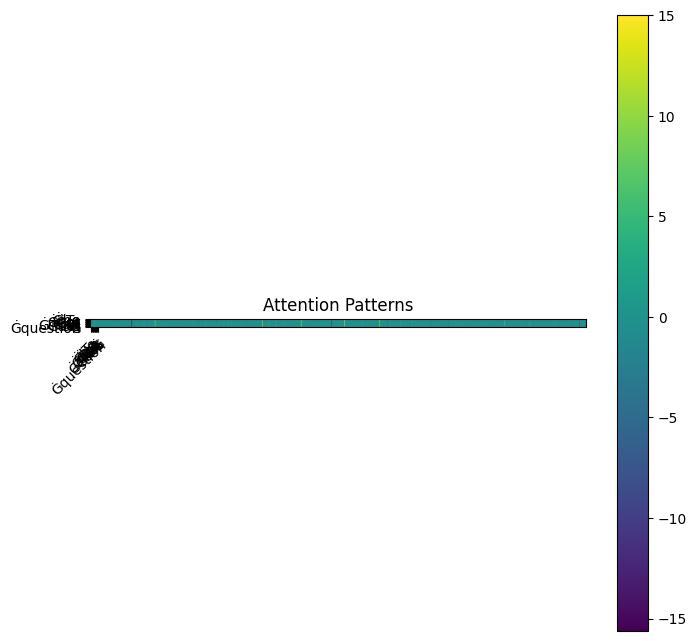

In [209]:
# diy with matplotlib + numpy! recall - self heads vs others. diagonal patterns.
%pip install matplotlib
import matplotlib.pyplot as plt
import numpy as np

# this is extensible to other types of attention (not just self attention)
def plot_attention_matrix(attention_mask, src_tokens, tgt_tokens):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(attention_mask, cmap='viridis')

    # add labels for tokens
    ax.set_xticks(np.arange(len(src_tokens)))
    ax.set_yticks(np.arange(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens)
    ax.set_yticklabels(tgt_tokens)

    # tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.colorbar(im)
    plt.title("Attention Patterns")
    plt.show()

# print cache entries 
print([k for k in cache.keys() if 'attn' in k and 'h.0' in k])
print(cache['transformer.h.0.attn'])
print(cache['transformer.h.0.attn'].shape)

plot_attention_matrix(src_tokens=tokenizer.convert_ids_to_tokens(tokens[0].tolist()), tgt_tokens=tokenizer.convert_ids_to_tokens(tokens[0].tolist()), attention_mask=cache['transformer.h.0.attn'].permute(1, 2, 0))

In [ ]:
class Attention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_Q = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_Q, std=self.cfg.init_range) # _ suffix means in-place method
        self.b_Q = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_K = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_K, std=self.cfg.init_range)
        self.b_K = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_V = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head))) # why the double braces?
        nn.init.normal_(self.W_V, std=self.cfg.init_range)
        self.b_V = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        
        self.W_O = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_head, cfg.d_model)))
        nn.init.normal_(self.W_O, std=self.cfg.init_range)
        self.b_O = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head, cfg.d_model)))
        
        # causal mask fill value
        self.register_buffer("IGNORE", torch.tensor(-1e5, dtype=torch.float32, device="cpu"))
        
    def forward(self, normalized_resid_pre): # input is normalized residual
        # normalized_resid_pre: [batch, position, d_model]
        if cfg.debug: print("Normalized Residual (Pre):", normalized_resid_pre.shape)
        
        # query, key - apply the Q and K weights/biases to the residual stream to get matrices of 
        # q: [batch, position n_heads, d_head]
        # v: [batch, key_pos, n_heads, d_head]
        # note einsums are linear maps
        # even though b_Q and b_K are of lower dimension, the trailing dimensions match
        q = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head", normalized_resid_pre, self.W_Q) + self.b_Q
        k = einsum("batch key_pos d_model, n_heads d_model d_head -> batch key_pos n_heads d_head", normalized_resid_pre, self.W_K) + self.b_K
        
        # attn scores are dot products of each pair of query, key - a matrix of [batch, n_heads, query_pos key_pos]
        # attn_scores are q by k transpose - model learns a "low-rank factorized matrix for each head", head learns d_model by d_model tensors?
        # W_O and W_V act on d_model dim, attention acts on position dimension - can permute order of applying attention
        attn_scores = einsum("batch query_pos n_heads d_head, batch key_pos n_heads d_head -> batch n_heads query_pos key_pos", q, k)
        attn_scores = attn_scores / math.sqrt(self.cfg.d_head)
        attn_scores = self.apply_causal_mask(attn_scores) # mask future positions
        
        attn = attn_scores.softmax(dim=-1) # [batch, n_head, query_pos, key_pos]
        
        # value is the info we're moving from source position (query) to destination position (value)
        # value is [batch, position, n_heads, d_head]
        v = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head", normalized_resid_pre, self.W_V) + self.b_V
        
        # z is the weighted result of how much info we're moving (attn_scores from q, k) and the info itself (from v)
        # z is [batch, query_pos, n_heads, d_head]
        z = einsum("batch n_heads query_pos key_pos, batch key_pos n_heads d_head -> batch query_pos n_heads d_head", attn, v)
        
        # attn_out is z applied to the residual stream, [batch, position, d_model]
        attn_out = einsum("batch query_pos n_heads d_head, n_heads d_head d_model -> batch query_pos d_model", z, self.W_O) + self.b_O
        return attn_out
        
    def apply_causal_mask(self, attn_scores): # we mask all positions above the diagonal
        # attn_scores: [batch, n_heads, query_pos, key_pos]
        mask = torch.triu(torch.ones(attn_scores.size(-2), attn_scores.size(-1), device=attn_scores.device), diagonal=1).bool()
        attn_scores.masked_fill_(mask, self.IGNORE) # mask with (infinitely) negative values?
        return attn_scores

In [ ]:
print([k for k in cache.keys() if 'h.0' in k and 'ln' in k])
print(reference_gpt2.transformer.h[0].attn.state_dict().keys())
print(list(Attention(cfg).state_dict().keys()))

['transformer.h.0.ln_1', 'transformer.h.0.ln_2']
odict_keys(['c_attn.weight', 'c_attn.bias', 'c_proj.weight', 'c_proj.bias'])
['W_Q', 'b_Q', 'W_K', 'b_K', 'W_V', 'b_V', 'W_O', 'b_O', 'IGNORE']


In [208]:
rand_float_test(Attention, [2, 4, 768])
load_gpt2_test(Attention, reference_gpt2.blocks[0].attn, cache["blocks.0.ln1.hook_normalized"])

Input shape: torch.Size([2, 4, 768])
Normalized Residual (Pre): torch.Size([2, 4, 768])


RuntimeError: The size of tensor a (12) must match the size of tensor b (768) at non-singleton dimension 2

# MLP

* Linear map, GELU, linear map
* All of the non-linear transformations live here

In [ ]:
class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_in = nn.Parameter(torch.empty((cfg.d_model, cfg.d_mlp)))
        nn.init.normal_(self.W_in, std=self.cfg.init_range)
        self.b_in = nn.Parameter(torch.zeros((cfg.d_mlp)))
        self.W_out = nn.Parameter(torch.empty((cfg.d_mlp, cfg.d_model)))
        nn.init.normal_(self.W_out, std=self.cfg.init_range)
        self.b_out = nn.Parameter(torch.zeros((cfg.d_model)))
        
    def forward(self, normalized_resid_mid):
        # normalized_resid_mid: [batch, position, d_model]
        if cfg.debug: print("Normalized Residual (Mid):", normalized_resid_mid.shape)
        # note pre is pre-activation, then GELU to get post-activation
        pre = einsum("batch position d_model, d_model d_mlp -> batch position d_mlp", normalized_resid_mid, self.W_in) + self.b_in
        post = gelu_new(pre)
        mlp_out = einsum("batch position d_mlp, d_mlp d_model -> batch position d_model", post, self.W_out) + self.b_out
        return mlp_out

In [ ]:
# tests here

# Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        
        self.ln1 = LayerNorm(cfg)
        self.attn = Attention(cfg)
        self.ln2 = LayerNorm(cfg)
        self.mlp = MLP(cfg)
        
    def forward(self, resid_pre):
        # resid_pre [batch, position, d_model]
        normalized_resid_pre = self.ln1(resid_pre)
        attn_out = self.attn(normalized_resid_pre)
        resid_mid = resid_pre + attn_out
        normalized_resid_mid = self.ln2(resid_mid)
        mlp_out = self.ml(normalized_resid_mid)
        resid_post = resid_mid + mlp_out
        return resid_post # go stare at the diagram!!! and then adapt
    
# tests

# Unembedding

- Transforms the final vector into a tensor of logits using a softmax function
$ softmax(x_i) = \frac{e^{x_i}}{\sum e^{x_j}} $
- This output is a tensor of logits, where we have one vector of size $d_{vocab}$ for each input token. 

$$
\begin{bmatrix}
a_0 & b_0 & ...\\
a_1 & b_1 & ...\\
... \\
a_{d} & b_d & ...
\end{bmatrix}
$$

In [ ]:
class Unembed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_U = nn.Parameter(torch.empty((cfg.d_model, cfg.d_vocab)))
        nn.init.normal_(self.W_U, std=self.cfg.init_range)
        self.b_U = nn.Parameter(torch.zeros((cfg.d_vocab))) # bias - not used in GPT 2, but if folding in layernorm, creates bias
        # add a requires_grad=False flag
    
    def forward(self, normalized_resid_final):
        # normalized_resid_final [batch, position, d_model]
        if cfg.debug: print("Normalized Residual (Final):", normalized_resid_final.shape)
        logits = einsum("batch position d_model, d_model d_vocab -> batch position d_vocab", normalized_resid_final, self.W_U) + self.b_U
        return logits

# Full Transformer

In [ ]:
class DemoTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embed = Embed(cfg)
        self.pos_embed = PosEmbed(cfg)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_final = LayerNorm(cfg)
        self.unembed = Unembed(cfg)
        
    def forward(self, tokens):
        # tokens [batch, position]
        embed = self.embed(tokens)
        pos_embed = self.pos_embed(tokens)
        residual = embed + pos_embed
        for block in self.blocks:
            residual = block(residual)
        normalized_resid_final = self.ln_final(residual)
        logits = self.unembed(normalized_resid_final)
        # logits [batch, position, logits]
        return logits
        

In [ ]:
rand_int_test(DemoTransformer, [2, 4])

# Using the Transformer

In [ ]:
demo_gpt2 = DemoTransformer(Config(debug=False))
demo_gpt2.load_state_dict(reference_gpt2.state_dict(), strict=False)

In [ ]:
test_string = """

"""

In [ ]:
test_tokens = tokenize(test_string)
demo_logits = demo_gpt2(test_tokens)